In [166]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [167]:
memprice=pd.read_csv("memory_prices.csv")

In [168]:
memprice.head(3)

,year,day_month,Company,Size in Kbyte,Cost in USD,Speed in nanosec,Memory Type,Ref,Page,JDR Chip Prices - Size Kbit,JDR Chip Prices - USD,JDR Chip Prices - nanosec
0,1957,NaN,C.C.C.,0.000977,392.0,10000,Flip-Flop transistor,Phister 366,366.0,NaN,NaN,NaN
1,1959,NaN,E.E.Co.,0.000977,64.8,10000,Flip-Flop - vacuum tube,Phister 366,366.0,NaN,NaN,NaN
2,1960,NaN,IBM,0.000977,5.0,11500,Core memory for IBM 1401,Phister 367,367.0,NaN,NaN,NaN


In [169]:
memprice.describe()

,year,Size in Kbyte,Cost in USD,Page,JDR Chip Prices - USD,JDR Chip Prices - nanosec
count,416.000000,4.160000e+02,416.000000,186.000000,127.000000,125.000000
mean,2001.108173,7.280771e+06,232.302452,234.134409,103.535118,114.400000
std,13.610603,1.415568e+07,378.297889,122.810371,200.698463,37.144009
min,1957.000000,9.765630e-04,0.300000,14.000000,2.950000,60.000000
25%,1991.000000,4.096000e+03,53.065000,143.000000,4.720000,80.000000
50%,2000.000000,6.553600e+04,94.740000,248.000000,12.450000,120.000000
75%,2013.000000,8.388608e+06,190.500000,321.750000,149.950000,150.000000
max,2024.000000,6.710886e+07,4680.000000,507.000000,1199.000000,200.000000


In [170]:
memprice.info()

<class 'pandas.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         416 non-null    int64  
 1   day_month                    410 non-null    str    
 2   Company                      402 non-null    str    
 3   Size in Kbyte                416 non-null    float64
 4   Cost in USD                  416 non-null    float64
 5   Speed in nanosec             230 non-null    str    
 6   Memory Type                  401 non-null    str    
 7   Ref                          400 non-null    str    
 8   Page                         186 non-null    float64
 9   JDR Chip Prices - Size Kbit  309 non-null    str    
 10  JDR Chip Prices - USD        127 non-null    float64
 11  JDR Chip Prices - nanosec    125 non-null    float64
dtypes: float64(5), int64(1), str(6)
memory usage: 39.1 KB


In [171]:
memprice.isna().sum()

year                             0
day_month                        6
Company                         14
Size in Kbyte                    0
Cost in USD                      0
Speed in nanosec               186
Memory Type                     15
Ref                             16
Page                           230
JDR Chip Prices - Size Kbit    107
JDR Chip Prices - USD          289
JDR Chip Prices - nanosec      291
dtype: int64

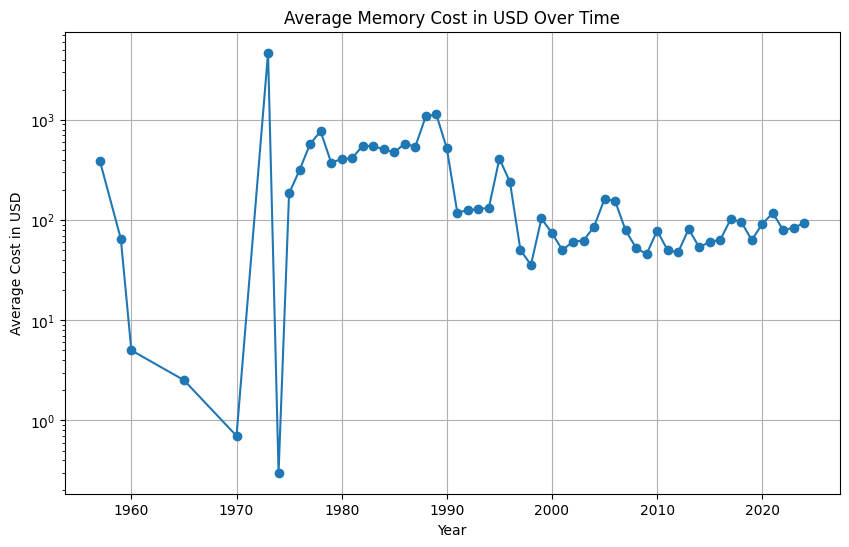

Memory Type
JDR MCT-ATMF 3MB Multifunc $169.90+3*36*12.45    10
2MB J-RAM-2 A&T $599                              7
JDR AT Multifuntion $199.95+49.95+318.60          7
JDR MCT-ATRAM 4MB $149.95+39.95+4*36*2.95         5
JDR MCT-ATMF 3MB Multifunction                    4
4Mx9-70 SIMM @ $110                               4
1Mx9-100 SIMM @ $30                               4
4Mx9-70 SIMM @ $129                               4
JDR MCT-ATMF 3MB Multifunc $169.90+426.60         3
1Mx9-100 SIMM @ $45                               3
Name: count, dtype: int64

In [172]:
# Group by year and calculate average cost
avg_cost_per_year = memprice.groupby('year')['Cost in USD'].mean().reset_index()

# Plot the average cost over time
plt.figure(figsize=(10, 6))
plt.plot(avg_cost_per_year['year'], avg_cost_per_year['Cost in USD'], marker='o')
plt.title('Average Memory Cost in USD Over Time')
plt.xlabel('Year')
plt.ylabel('Average Cost in USD')
plt.yscale('log')  # Log scale because prices vary greatly
plt.grid(True)
plt.show()

# Also, let's see the distribution of memory types
memprice['Memory Type'].value_counts().head(10)

In [173]:
memprice.duplicated().sum()

np.int64(0)

In [174]:
memprice[memprice['Memory Type'].str.contains('SIMM', na=False)]

,year,day_month,Company,Size in Kbyte,Cost in USD,Speed in nanosec,Memory Type,Ref,Page,JDR Chip Prices - Size Kbit,JDR Chip Prices - USD,JDR Chip Prices - nanosec
94,1990,Oct,IC Express,1024.0,59.0,80,1Mx9-80 SIMM @ $59,BYTE,343.0,1024,11.95,120.0
95,1990,Nov,IC Express,1024.0,51.0,80,1Mx9-80 SIMM @ $51,BYTE,453.0,1024,11.95,120.0
96,1990,Dec,IC Express,1024.0,45.5,80,1Mx9-80 SIMM @ $45.50,BYTE,388.0,1024,7.95,120.0
97,1991,Jan,IC Express,1024.0,44.5,80,1Mx9-80 SIMM @ $44.50,BYTE,393.0,1024,7.95,120.0
98,1991,Feb,IC Express,1024.0,44.5,80,1Mx9-80 SIMM @ $44.50,BYTE,335.0,1024,7.95,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...
189,1998,Oct20,Computer Services,32768.0,37.0,NaN,8Mx32-? SIMM EDO [72 pin] @ $37,Pcmag,293.0,NaN,NaN,NaN
190,1998,Nov17,Discount Memory,32768.0,27.0,NaN,8Mx32-? SIMM FPM [72 pin] @ $27,Pcmag,286.0,NaN,NaN,NaN
191,1998,Dec1,Discount Memory,32768.0,27.0,NaN,8Mx32-? SIMM FPM [72 pin] @ $27,Pcmag,390.0,NaN,NaN,NaN
192,1999,Feb9,Memory Liquidators,32768.0,46.0,NaN,8Mx32-? SIMM FPM [72 pin] @ $46,Pcmag,263.0,NaN,NaN,NaN


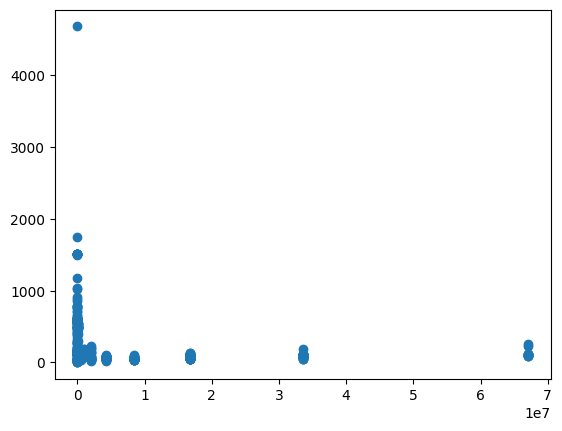

In [175]:
plt.scatter(memprice['Size in Kbyte'], memprice['Cost in USD'])


In [176]:
memprice['decade'] = (memprice['year'] // 10) * 10

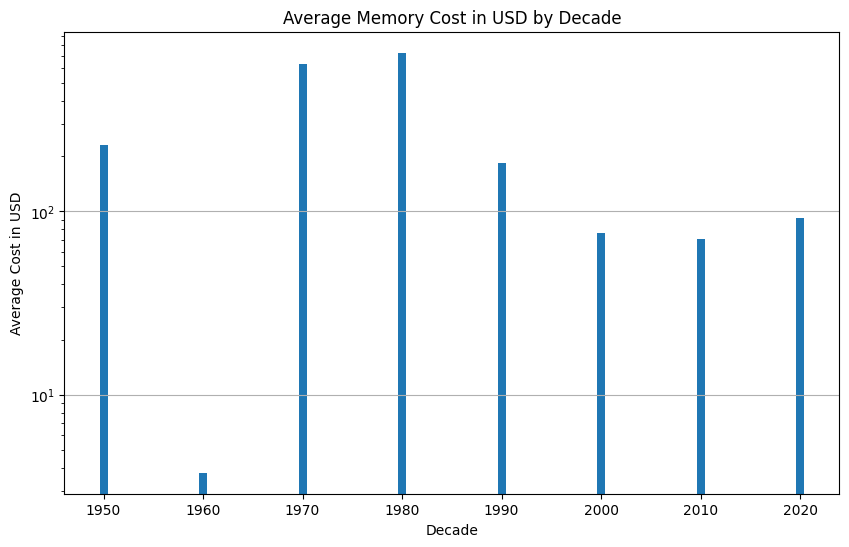

In [177]:
# Create a decade column
memprice['decade'] = (memprice['year'] // 10) * 10

# Group by decade and calculate average cost
avg_cost_per_decade = memprice.groupby('decade')['Cost in USD'].mean().reset_index()

# Plot the average cost per decade
plt.figure(figsize=(10, 6))
plt.bar(avg_cost_per_decade['decade'], avg_cost_per_decade['Cost in USD'])
plt.title('Average Memory Cost in USD by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Cost in USD')
plt.yscale('log')  # Log scale for better visualization
plt.xticks(avg_cost_per_decade['decade'])
plt.grid(True, axis='y')
plt.show()

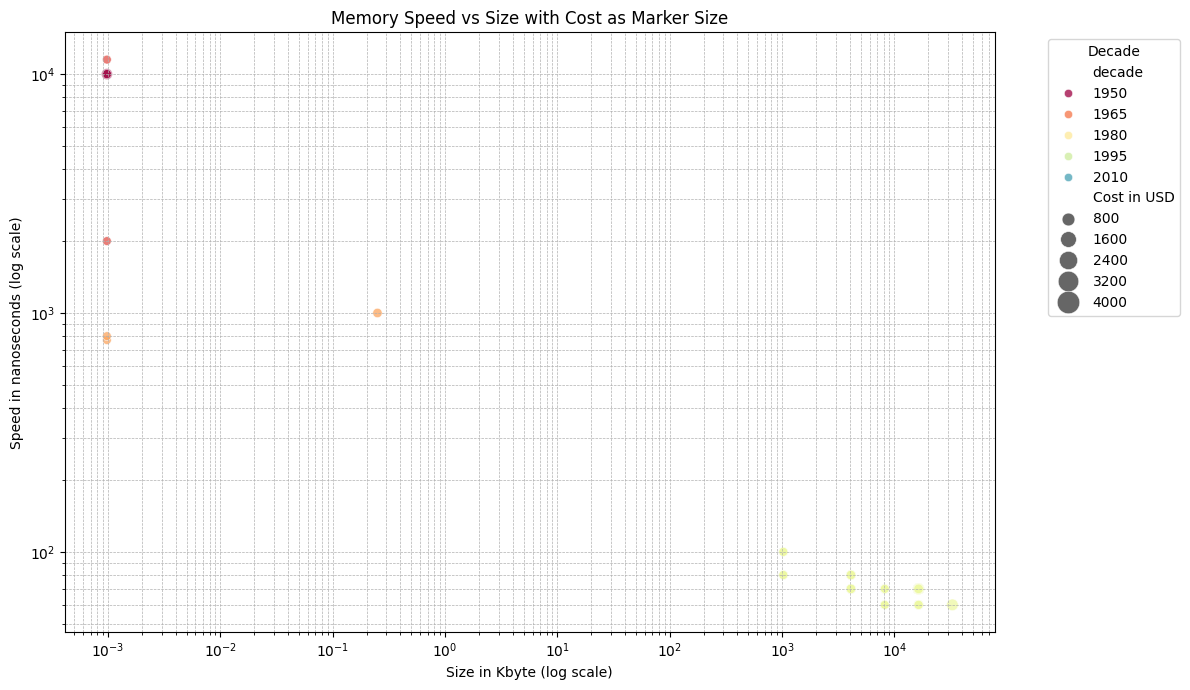

In [178]:
# Convert speed and cost values to numeric and plot size vs speed with cost as marker size
memprice['Speed in nanosec'] = pd.to_numeric(memprice['Speed in nanosec'], errors='coerce')
memprice['Cost in USD'] = pd.to_numeric(memprice['Cost in USD'], errors='coerce')

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=memprice,
    x='Size in Kbyte',
    y='Speed in nanosec',
    hue='decade',
    size='Cost in USD',
    sizes=(40, 300),
    palette='Spectral',
    alpha=0.75,
    edgecolor='w',
    linewidth=0.5
)
plt.xscale('log')
plt.yscale('log')
plt.title('Memory Speed vs Size with Cost as Marker Size')
plt.xlabel('Size in Kbyte (log scale)')
plt.ylabel('Speed in nanoseconds (log scale)')
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [179]:
# Check missing ratio
missing_ratio = memprice.isna().mean().sort_values(ascending=False)
print(missing_ratio)

Speed in nanosec               0.788462
JDR Chip Prices - nanosec      0.699519
JDR Chip Prices - USD          0.694712
Page                           0.552885
JDR Chip Prices - Size Kbit    0.257212
Ref                            0.038462
Memory Type                    0.036058
Company                        0.033654
day_month                      0.014423
Cost in USD                    0.000000
Size in Kbyte                  0.000000
year                           0.000000
decade                         0.000000
dtype: float64


In [180]:
# Drop columns with more than 50% missing values
cols_to_drop = missing_ratio[missing_ratio > 0.5].index.tolist()
memprice_clean = memprice.drop(columns=cols_to_drop)
memprice_clean.head()

,year,day_month,Company,Size in Kbyte,Cost in USD,Memory Type,Ref,JDR Chip Prices - Size Kbit,decade
0,1957,NaN,C.C.C.,0.000977,392.00,Flip-Flop transistor,Phister 366,NaN,1950
1,1959,NaN,E.E.Co.,0.000977,64.80,Flip-Flop - vacuum tube,Phister 366,NaN,1950
2,1960,NaN,IBM,0.000977,5.00,Core memory for IBM 1401,Phister 367,NaN,1960
3,1965,NaN,IBM,0.000977,2.52,Core Memory for IBM 360/30,Phister 367,NaN,1960
4,1970,NaN,IBM,0.000977,0.70,Core Memory for IBM 370/135,Phister 367,NaN,1970


In [181]:
memprice.describe()

,year,Size in Kbyte,Cost in USD,Speed in nanosec,Page,JDR Chip Prices - USD,JDR Chip Prices - nanosec,decade
count,416.000000,4.160000e+02,416.000000,88.000000,186.000000,127.000000,125.000000,416.000000
mean,2001.108173,7.280771e+06,232.302452,479.204545,234.134409,103.535118,114.400000,1996.562500
std,13.610603,1.415568e+07,378.297889,1914.082849,122.810371,200.698463,37.144009,14.276476
min,1957.000000,9.765630e-04,0.300000,60.000000,14.000000,2.950000,60.000000,1950.000000
25%,1991.000000,4.096000e+03,53.065000,70.000000,143.000000,4.720000,80.000000,1990.000000
50%,2000.000000,6.553600e+04,94.740000,75.000000,248.000000,12.450000,120.000000,2000.000000
75%,2013.000000,8.388608e+06,190.500000,80.000000,321.750000,149.950000,150.000000,2010.000000
max,2024.000000,6.710886e+07,4680.000000,11500.000000,507.000000,1199.000000,200.000000,2020.000000


In [182]:
memprice_clean.describe()

,year,Size in Kbyte,Cost in USD,decade
count,416.000000,4.160000e+02,416.000000,416.000000
mean,2001.108173,7.280771e+06,232.302452,1996.562500
std,13.610603,1.415568e+07,378.297889,14.276476
min,1957.000000,9.765630e-04,0.300000,1950.000000
25%,1991.000000,4.096000e+03,53.065000,1990.000000
50%,2000.000000,6.553600e+04,94.740000,2000.000000
75%,2013.000000,8.388608e+06,190.500000,2010.000000
max,2024.000000,6.710886e+07,4680.000000,2020.000000


In [183]:
keep_columns = ['year', 'day_month', 'Company', 'Size in Kbyte', 'Cost in USD',
                'Speed in nanosec', 'Memory Type', 'decade']
memprice_clean2 = memprice[keep_columns].copy()

In [184]:
memprice_clean2 .describe()

,year,Size in Kbyte,Cost in USD,Speed in nanosec,decade
count,416.000000,4.160000e+02,416.000000,88.000000,416.000000
mean,2001.108173,7.280771e+06,232.302452,479.204545,1996.562500
std,13.610603,1.415568e+07,378.297889,1914.082849,14.276476
min,1957.000000,9.765630e-04,0.300000,60.000000,1950.000000
25%,1991.000000,4.096000e+03,53.065000,70.000000,1990.000000
50%,2000.000000,6.553600e+04,94.740000,75.000000,2000.000000
75%,2013.000000,8.388608e+06,190.500000,80.000000,2010.000000
max,2024.000000,6.710886e+07,4680.000000,11500.000000,2020.000000


In [185]:
avg_cost_per_decade = memprice_clean.groupby('decade')['Cost in USD'].mean().reset_index()
avg_cost_per_decade

,decade,Cost in USD
0,1950,228.400000
1,1960,3.760000
2,1970,630.800000
3,1980,730.412222
4,1990,183.188435
5,2000,75.743253
6,2010,70.414651
7,2020,91.833556


In [186]:
# Separate string data - example: split 'Memory Type' into words
memprice['Memory_Type_Words'] = memprice['Memory Type'].str.split(' ', expand=False)
print(memprice[['Memory Type', 'Memory_Type_Words']].head())

# Extract first word as category
memprice['Memory_Category'] = memprice['Memory Type'].str.split(' ').str[0]
print(memprice[['Memory Type', 'Memory_Category']].head())

# Filter by category
simm_data = memprice[memprice['Memory_Category'] == 'SIMM']
print(simm_data[['Memory Type', 'Memory_Category']].head())

                   Memory Type                  Memory_Type_Words
0         Flip-Flop transistor            [Flip-Flop, transistor]
1      Flip-Flop - vacuum tube       [Flip-Flop, -, vacuum, tube]
2     Core memory for IBM 1401     [Core, memory, for, IBM, 1401]
3   Core Memory for IBM 360/30   [Core, Memory, for, IBM, 360/30]
4  Core Memory for IBM 370/135  [Core, Memory, for, IBM, 370/135]
                   Memory Type Memory_Category
0         Flip-Flop transistor       Flip-Flop
1      Flip-Flop - vacuum tube       Flip-Flop
2     Core memory for IBM 1401            Core
3   Core Memory for IBM 360/30            Core
4  Core Memory for IBM 370/135            Core
Empty DataFrame
Columns: [Memory Type, Memory_Category]
Index: []


In [187]:
memprice['Memory_Category'].value_counts()

Memory_Category
2x8          41
JDR          33
2x16         26
4Mx9-80      24
2x4          20
2x1          18
2x2          18
512          16
64           15
8Mx32-?      14
128          14
4Mx36-70     13
4Mx9-70      12
2x32         12
256          10
Bocaram       9
2MB           8
1Mx9-100      8
1x8           8
Altair        6
1x32          6
IBM           5
1Mx9-80       5
2Mx32-60      5
1x4           5
Core          4
1GB           4
1x16          4
Everex        3
4Mx3x3-70     3
Flip-Flop     2
S-100         2
2Mx36-70      2
4Mx32-60      2
4Mx36-60      2
2Mx32-70      2
2Mx32-?       2
???           2
2x512         2
1             2
IC            1
SD            1
8K            1
S-100,        1
Pine          1
AST           1
Unitex        1
4Mx9-??       1
4Mx36-??      1
8Mx36-60      1
4Mx64-?       1
1x2           1
Name: count, dtype: int64

In [188]:
# Drop the 'day_month' column
memprice_no_day_month= memprice.drop(columns=['day_month'])
print("Column 'day_month' dropped.")
print(memprice_no_day_month.head())

Column 'day_month' dropped.
   year  Company  Size in Kbyte  Cost in USD  Speed in nanosec  \
0  1957   C.C.C.       0.000977       392.00           10000.0   
1  1959  E.E.Co.       0.000977        64.80           10000.0   
2  1960      IBM       0.000977         5.00           11500.0   
3  1965      IBM       0.000977         2.52            2000.0   
4  1970      IBM       0.000977         0.70             770.0   

                   Memory Type          Ref   Page  \
0         Flip-Flop transistor  Phister 366  366.0   
1      Flip-Flop - vacuum tube  Phister 366  366.0   
2     Core memory for IBM 1401  Phister 367  367.0   
3   Core Memory for IBM 360/30  Phister 367  367.0   
4  Core Memory for IBM 370/135  Phister 367  367.0   

  JDR Chip Prices - Size Kbit  JDR Chip Prices - USD  \
0                         NaN                    NaN   
1                         NaN                    NaN   
2                         NaN                    NaN   
3                         

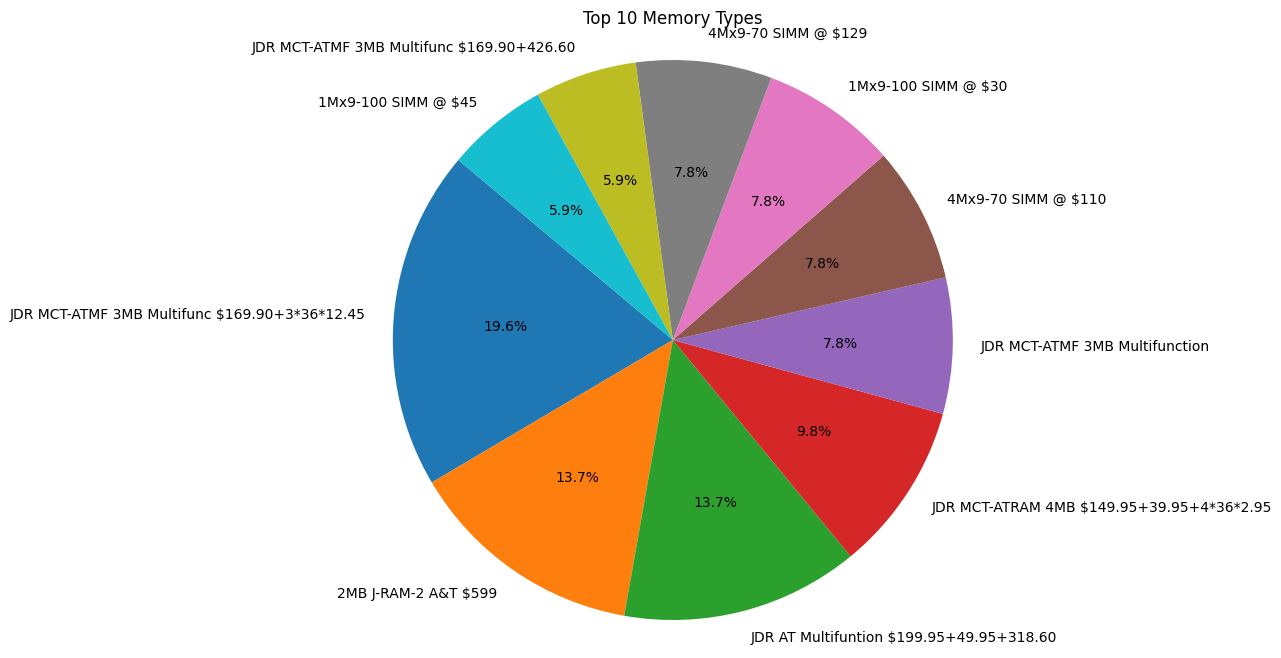

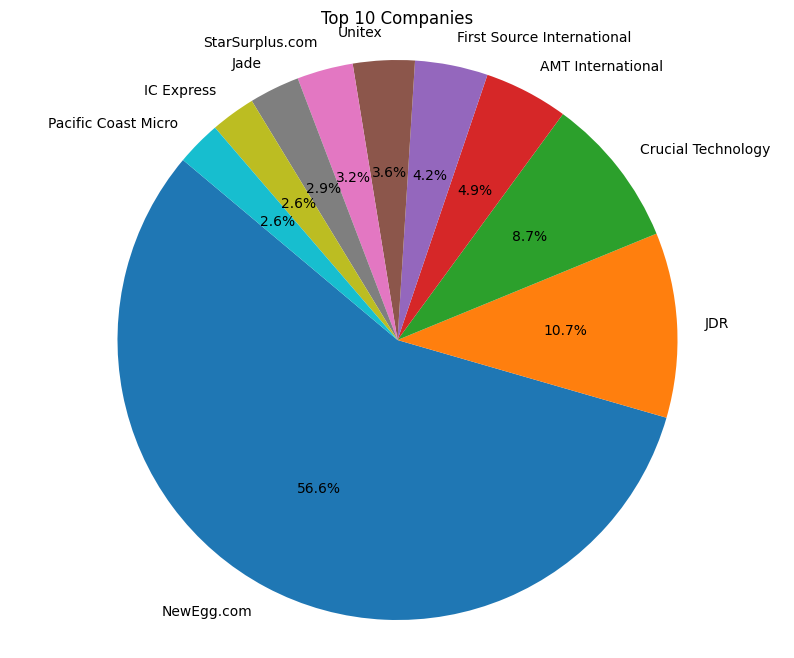

In [189]:
# Pie chart for Memory Type (top 10)
memory_type_counts = memprice['Memory Type'].value_counts().head(10)
plt.figure(figsize=(10, 8))
plt.pie(memory_type_counts, labels=memory_type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Memory Types')
plt.axis('equal')
plt.show()

# Pie chart for Company (top 10)
company_counts = memprice['Company'].value_counts().head(10)
plt.figure(figsize=(10, 8))
plt.pie(company_counts, labels=company_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Companies')
plt.axis('equal')
plt.show()

In [190]:
memprice.describe()

,year,Size in Kbyte,Cost in USD,Speed in nanosec,Page,JDR Chip Prices - USD,JDR Chip Prices - nanosec,decade
count,416.000000,4.160000e+02,416.000000,88.000000,186.000000,127.000000,125.000000,416.000000
mean,2001.108173,7.280771e+06,232.302452,479.204545,234.134409,103.535118,114.400000,1996.562500
std,13.610603,1.415568e+07,378.297889,1914.082849,122.810371,200.698463,37.144009,14.276476
min,1957.000000,9.765630e-04,0.300000,60.000000,14.000000,2.950000,60.000000,1950.000000
25%,1991.000000,4.096000e+03,53.065000,70.000000,143.000000,4.720000,80.000000,1990.000000
50%,2000.000000,6.553600e+04,94.740000,75.000000,248.000000,12.450000,120.000000,2000.000000
75%,2013.000000,8.388608e+06,190.500000,80.000000,321.750000,149.950000,150.000000,2010.000000
max,2024.000000,6.710886e+07,4680.000000,11500.000000,507.000000,1199.000000,200.000000,2020.000000


In [191]:
memprice.info()

<class 'pandas.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         416 non-null    int64  
 1   day_month                    410 non-null    str    
 2   Company                      402 non-null    str    
 3   Size in Kbyte                416 non-null    float64
 4   Cost in USD                  416 non-null    float64
 5   Speed in nanosec             88 non-null     float64
 6   Memory Type                  401 non-null    str    
 7   Ref                          400 non-null    str    
 8   Page                         186 non-null    float64
 9   JDR Chip Prices - Size Kbit  309 non-null    str    
 10  JDR Chip Prices - USD        127 non-null    float64
 11  JDR Chip Prices - nanosec    125 non-null    float64
 12  decade                       416 non-null    int64  
 13  Memory_Type_Words            40

In [192]:
memprice_no_day_month.info()

<class 'pandas.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         416 non-null    int64  
 1   Company                      402 non-null    str    
 2   Size in Kbyte                416 non-null    float64
 3   Cost in USD                  416 non-null    float64
 4   Speed in nanosec             88 non-null     float64
 5   Memory Type                  401 non-null    str    
 6   Ref                          400 non-null    str    
 7   Page                         186 non-null    float64
 8   JDR Chip Prices - Size Kbit  309 non-null    str    
 9   JDR Chip Prices - USD        127 non-null    float64
 10  JDR Chip Prices - nanosec    125 non-null    float64
 11  decade                       416 non-null    int64  
 12  Memory_Type_Words            401 non-null    object 
 13  Memory_Category              40

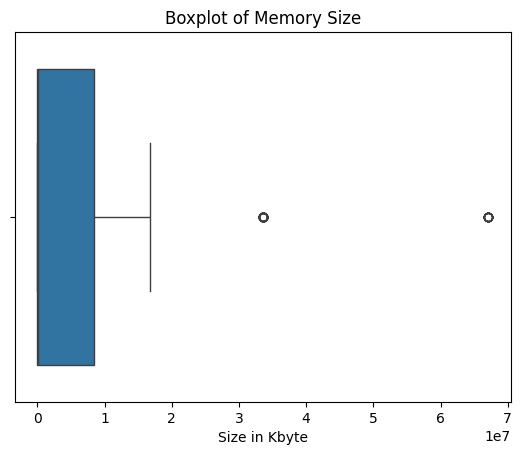

In [193]:
sns.boxplot(x=memprice['Size in Kbyte'])
plt.title('Boxplot of Memory Size')
plt.show()

In [194]:


# Function to calculate mean without outliers
def mean_non_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    non_outliers = data[(data >= lower_bound) & (data <= upper_bound)]
    return non_outliers.mean()

# Apply to your data
mean_cost_no_outliers = mean_non_outliers(memprice['Cost in USD'])
print(f"Mean cost without outliers: ${mean_cost_no_outliers:.2f}")

# Compare with regular mean
regular_mean = memprice['Cost in USD'].mean()
print(f"Regular mean: ${regular_mean:.2f}")

Mean cost without outliers: $90.40
Regular mean: $232.30
